<a href="https://colab.research.google.com/github/Kishoby/Conceptual-Research_Hybrid-Approach/blob/Multi-Target/MultiTargets_XAI_ARIMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import gc
import warnings

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.api import VAR

warnings.filterwarnings("ignore")

In [2]:

multi_target_df = pd.read_csv("/content/drive/MyDrive/Research v2/Research 18.03.2026/Multi Target/cleaned_multi_target_dataset (1).csv")

print("Dataset shape:", multi_target_df.shape)
multi_target_df.head()

Dataset shape: (130003, 18)


,visibility_km,last_updated_epoch,air_quality_Ozone,latitude,air_quality_PM10,condition_text,air_quality_Sulphur_dioxide,uv_index,air_quality_Nitrogen_dioxide,feels_like_celsius,precip_mm,cloud,pressure_mb,longitude,air_quality_Carbon_Monoxide,air_quality_PM2.5,temperature_celsius,humidity
0,16.0,1715849100,62.2,46.60,7.1,2,0.2,1.0,2.5,16.1,0.00,0,1012.0,-120.49,198.6,6.3,16.1,58
1,10.0,1715849100,23.3,14.10,25.3,32,1.4,1.0,3.7,25.3,0.28,37,1017.0,-87.22,377.2,19.0,23.0,78
2,10.0,1715849100,5.9,13.71,28.1,23,7.5,1.0,7.7,30.2,0.30,50,1010.0,-89.20,460.6,20.4,26.0,94
3,5.0,1715849100,0.4,14.62,178.1,19,19.3,1.0,35.0,20.0,0.09,100,1019.0,-90.53,2243.0,132.0,20.0,88
4,10.0,1715849100,34.0,17.25,32.1,30,0.2,1.0,0.3,29.6,0.00,94,1007.0,-88.77,307.1,7.7,26.0,89


In [3]:

targets = [
    "air_quality_PM2.5",
    "temperature_celsius",
    "humidity"
]

stat_df = multi_target_df[targets].copy()

print("Statistical dataset shape:", stat_df.shape)
stat_df.head()

Statistical dataset shape: (130003, 3)


,air_quality_PM2.5,temperature_celsius,humidity
0,6.3,16.1,58
1,19.0,23.0,78
2,20.4,26.0,94
3,132.0,20.0,88
4,7.7,26.0,89


In [4]:

split_index = int(0.8 * len(stat_df))

train_df = stat_df.iloc[:split_index].copy()
test_df = stat_df.iloc[split_index:].copy()

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

Train shape: (104002, 3)
Test shape : (26001, 3)


In [5]:
def calculate_metrics_series(y_true, y_pred, model_name, dataset_type, target_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    acc = r2 * 100

    return pd.DataFrame([[
        dataset_type,
        model_name,
        target_name,
        mse,
        rmse,
        mae,
        r2,
        acc
    ]], columns=["Dataset", "Model", "Target", "MSE", "RMSE", "MAE", "R2", "Accuracy (%)"]).round(3)

In [6]:

arima_training_results = []
arima_testing_results = []

for target in targets:
    print(f"\nRunning ARIMA for {target}")

    train_series = train_df[target]
    test_series = test_df[target]

    # light ARIMA
    arima_model = ARIMA(
        train_series,
        order=(1, 1, 1)
    )
    arima_fit = arima_model.fit()

    # training prediction
    train_pred = arima_fit.predict(start=1, end=len(train_series) - 1)
    train_actual = train_series.iloc[1:]

    arima_training_results.append(
        calculate_metrics_series(
            train_actual,
            train_pred,
            model_name="ARIMA",
            dataset_type="Training",
            target_name=target
        )
    )

    # testing forecast
    test_pred = arima_fit.forecast(steps=len(test_series))

    arima_testing_results.append(
        calculate_metrics_series(
            test_series,
            test_pred,
            model_name="ARIMA",
            dataset_type="Testing",
            target_name=target
        )
    )

    del arima_model, arima_fit, train_pred, test_pred
    gc.collect()


Running ARIMA for air_quality_PM2.5

Running ARIMA for temperature_celsius

Running ARIMA for humidity


In [7]:

arima_training_table = pd.concat(arima_training_results, ignore_index=True)
arima_testing_table = pd.concat(arima_testing_results, ignore_index=True)

print("ARIMA TRAINING RESULTS")
display(arima_training_table)

print("ARIMA TESTING RESULTS")
display(arima_testing_table)

ARIMA TRAINING RESULTS


,Dataset,Model,Target,MSE,RMSE,MAE,R2,Accuracy (%)
0,Training,ARIMA,air_quality_PM2.5,1543.698,39.290,19.623,0.031,3.086
1,Training,ARIMA,temperature_celsius,64.727,8.045,6.242,0.174,17.351
2,Training,ARIMA,humidity,405.115,20.127,15.781,0.306,30.550


ARIMA TESTING RESULTS


,Dataset,Model,Target,MSE,RMSE,MAE,R2,Accuracy (%)
0,Testing,ARIMA,air_quality_PM2.5,610.825,24.715,13.870,-0.020,-2.025
1,Testing,ARIMA,temperature_celsius,155.339,12.464,9.273,-0.251,-25.074
2,Testing,ARIMA,humidity,741.477,27.230,24.380,-0.547,-54.673


In [8]:

training_table = pd.concat([
    arima_training_table

], ignore_index=True)

print("FINAL TRAINING TABLE")
display(training_table)

FINAL TRAINING TABLE


,Dataset,Model,Target,MSE,RMSE,MAE,R2,Accuracy (%)
0,Training,ARIMA,air_quality_PM2.5,1543.698,39.290,19.623,0.031,3.086
1,Training,ARIMA,temperature_celsius,64.727,8.045,6.242,0.174,17.351
2,Training,ARIMA,humidity,405.115,20.127,15.781,0.306,30.550


In [9]:
targets = [
    "air_quality_PM2.5",
    "temperature_celsius",
    "humidity"
]

In [10]:
# ============================================================
# MULTI-TARGET ARIMA EXPLAINABILITY
# Targets: PM2.5, Temperature, Humidity
# Model: Separate ARIMA(1,1,1) for each target
# Saves all charts and tables and downloads one ZIP file
# ============================================================

import os
import re
import zipfile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera
from statsmodels.graphics.gofplots import qqplot

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

warnings.filterwarnings("ignore")

save_dir = "/content/Multi_Target_ARIMA_XAI_Outputs"
os.makedirs(save_dir, exist_ok=True)

targets = [
    "air_quality_PM2.5",
    "temperature_celsius",
    "humidity"
]

ARIMA_ORDER = (1, 1, 1)

def safe_name(value):
    return re.sub(
        r"[^A-Za-z0-9_]+",
        "_",
        str(value)
    )

print("Output folder:", save_dir)
print("Targets:", targets)
print("ARIMA order:", ARIMA_ORDER)

Output folder: /content/Multi_Target_ARIMA_XAI_Outputs
Targets: ['air_quality_PM2.5', 'temperature_celsius', 'humidity']
ARIMA order: (1, 1, 1)


In [11]:
# ============================================================
# FIT ARIMA MODELS FOR ALL TARGETS
# ============================================================

arima_results = {}
metrics_rows = []
coefficient_tables = []
diagnostic_rows = []
residual_statistics_rows = []

for target in targets:

    print(f"\nFitting ARIMA for: {target}")

    train_series = (
        pd.to_numeric(
            train_df[target],
            errors="coerce"
        )
        .dropna()
        .astype(float)
    )

    test_series = (
        pd.to_numeric(
            test_df[target],
            errors="coerce"
        )
        .dropna()
        .astype(float)
    )

    arima_model = ARIMA(
        train_series,
        order=ARIMA_ORDER
    )

    arima_fit = arima_model.fit()

    # Forecast with confidence intervals
    forecast_result = arima_fit.get_forecast(
        steps=len(test_series)
    )

    forecast_mean = np.asarray(
        forecast_result.predicted_mean,
        dtype=float
    )

    confidence_interval = forecast_result.conf_int(
        alpha=0.05
    )

    lower_ci = np.asarray(
        confidence_interval.iloc[:, 0],
        dtype=float
    )

    upper_ci = np.asarray(
        confidence_interval.iloc[:, 1],
        dtype=float
    )

    y_true = test_series.to_numpy(dtype=float)
    y_pred = forecast_mean

    residuals = y_true - y_pred
    absolute_error = np.abs(residuals)

    mse = mean_squared_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(mse)

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    metrics_rows.append({
        "Model": "ARIMA",
        "Order": str(ARIMA_ORDER),
        "Target": target,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "R2_Percentage": r2 * 100,
        "AIC": arima_fit.aic,
        "BIC": arima_fit.bic,
        "HQIC": arima_fit.hqic
    })

    # Parameter table
    parameter_df = pd.DataFrame({
        "Target": target,
        "Parameter": arima_fit.params.index,
        "Coefficient": arima_fit.params.values,
        "Standard_Error": arima_fit.bse.values,
        "Z_or_T_Value": arima_fit.tvalues.values,
        "P_Value": arima_fit.pvalues.values
    })

    parameter_df["Significant_At_0.05"] = (
        parameter_df["P_Value"] < 0.05
    )

    parameter_df["Absolute_Coefficient"] = (
        parameter_df["Coefficient"].abs()
    )

    coefficient_tables.append(parameter_df)

    parameter_df.to_csv(
        f"{save_dir}/ARIMA_Coefficients_{safe_name(target)}.csv",
        index=False
    )

    # Ljung-Box test
    fitted_residuals = pd.Series(
        arima_fit.resid
    ).dropna()

    ljung_lag = min(
        20,
        max(1, len(fitted_residuals) // 5)
    )

    ljung_result = acorr_ljungbox(
        fitted_residuals,
        lags=[ljung_lag],
        return_df=True
    )

    # Jarque-Bera test
    jb_statistic, jb_pvalue, skewness, kurtosis = (
        jarque_bera(fitted_residuals)
    )

    diagnostic_rows.append({
        "Target": target,
        "Ljung_Box_Lag": ljung_lag,
        "Ljung_Box_Statistic":
            ljung_result["lb_stat"].iloc[0],
        "Ljung_Box_P_Value":
            ljung_result["lb_pvalue"].iloc[0],
        "Residuals_Uncorrelated":
            ljung_result["lb_pvalue"].iloc[0] > 0.05,
        "Jarque_Bera_Statistic": jb_statistic,
        "Jarque_Bera_P_Value": jb_pvalue,
        "Residuals_Normal":
            jb_pvalue > 0.05,
        "Skewness": skewness,
        "Kurtosis": kurtosis
    })

    residual_statistics_rows.append({
        "Target": target,
        "Residual_Mean": np.mean(residuals),
        "Residual_Standard_Deviation":
            np.std(residuals),
        "Residual_Minimum": np.min(residuals),
        "Residual_Maximum": np.max(residuals),
        "Mean_Absolute_Error": np.mean(
            absolute_error
        ),
        "Median_Absolute_Error": np.median(
            absolute_error
        )
    })

    prediction_df = pd.DataFrame({
        "Actual": y_true,
        "Forecast": y_pred,
        "Lower_95_CI": lower_ci,
        "Upper_95_CI": upper_ci,
        "Residual": residuals,
        "Absolute_Error": absolute_error
    })

    prediction_df.to_csv(
        f"{save_dir}/ARIMA_Predictions_{safe_name(target)}.csv",
        index=False
    )

    arima_results[target] = {
        "model": arima_model,
        "fit": arima_fit,
        "train": train_series,
        "test": test_series,
        "actual": y_true,
        "forecast": y_pred,
        "lower_ci": lower_ci,
        "upper_ci": upper_ci,
        "residuals": residuals,
        "absolute_error": absolute_error,
        "fitted_residuals": fitted_residuals,
        "parameters": parameter_df
    }

    print("Completed:", target)


Fitting ARIMA for: air_quality_PM2.5
Completed: air_quality_PM2.5

Fitting ARIMA for: temperature_celsius
Completed: temperature_celsius

Fitting ARIMA for: humidity
Completed: humidity


In [12]:
# ============================================================
# SAVE COMBINED TABLES
# ============================================================

metrics_df = pd.DataFrame(
    metrics_rows
)

all_coefficients_df = pd.concat(
    coefficient_tables,
    ignore_index=True
)

diagnostics_df = pd.DataFrame(
    diagnostic_rows
)

residual_statistics_df = pd.DataFrame(
    residual_statistics_rows
)

metrics_df.to_csv(
    f"{save_dir}/ARIMA_All_Targets_Metrics.csv",
    index=False
)

all_coefficients_df.to_csv(
    f"{save_dir}/ARIMA_All_Targets_Coefficients.csv",
    index=False
)

diagnostics_df.to_csv(
    f"{save_dir}/ARIMA_All_Targets_Diagnostics.csv",
    index=False
)

residual_statistics_df.to_csv(
    f"{save_dir}/ARIMA_All_Targets_Residual_Statistics.csv",
    index=False
)

print("ARIMA metrics")
display(metrics_df.round(4))

print("ARIMA coefficients")
display(all_coefficients_df.round(4))

print("Diagnostic tests")
display(diagnostics_df.round(4))

print("Residual statistics")
display(residual_statistics_df.round(4))

ARIMA metrics


,Model,Order,Target,MSE,RMSE,MAE,R2,R2_Percentage,AIC,BIC,HQIC
0,ARIMA,"(1, 1, 1)",air_quality_PM2.5,610.8250,24.7149,13.8699,-0.0202,-2.0247,1.058713e+06,1.058742e+06,1.058722e+06
1,ARIMA,"(1, 1, 1)",temperature_celsius,155.3393,12.4635,9.2732,-0.2507,-25.0743,7.288519e+05,7.288805e+05,7.288605e+05
2,ARIMA,"(1, 1, 1)",humidity,741.4766,27.2301,24.3800,-0.5467,-54.6728,9.195881e+05,9.196168e+05,9.195968e+05


ARIMA coefficients


,Target,Parameter,Coefficient,Standard_Error,Z_or_T_Value,P_Value,Significant_At_0.05,Absolute_Coefficient
0,air_quality_PM2.5,ar.L1,0.0527,0.0027,19.7203,0.0000,True,0.0527
1,air_quality_PM2.5,ma.L1,-0.9988,0.0002,-5709.1203,0.0000,True,0.9988
2,air_quality_PM2.5,sigma2,1543.5245,0.7078,2180.8307,0.0000,True,1543.5245
3,temperature_celsius,ar.L1,0.0309,0.0030,10.3903,0.0000,True,0.0309
4,temperature_celsius,ma.L1,-0.9193,0.0012,-744.9221,0.0000,True,0.9193
5,temperature_celsius,sigma2,64.7262,0.2453,263.9059,0.0000,True,64.7262
6,humidity,ar.L1,-0.0004,0.0033,-0.1271,0.8988,False,0.0004
7,humidity,ma.L1,-0.8582,0.0018,-472.4307,0.0000,True,0.8582
8,humidity,sigma2,405.1105,1.7176,235.8564,0.0000,True,405.1105


Diagnostic tests


,Target,Ljung_Box_Lag,Ljung_Box_Statistic,Ljung_Box_P_Value,Residuals_Uncorrelated,Jarque_Bera_Statistic,Jarque_Bera_P_Value,Residuals_Normal,Skewness,Kurtosis
0,air_quality_PM2.5,20,1917.2939,0.0,False,1.452856e+08,0.0,False,9.4403,185.1272
1,temperature_celsius,20,160.8226,0.0,False,7.040153e+03,0.0,False,-0.4776,3.8440
2,humidity,20,212.7512,0.0,False,2.092684e+03,0.0,False,-0.3381,3.1599


Residual statistics


,Target,Residual_Mean,Residual_Standard_Deviation,Residual_Minimum,Residual_Maximum,Mean_Absolute_Error,Median_Absolute_Error
0,air_quality_PM2.5,3.4817,24.4684,-15.7121,430.2879,13.8699,9.5121
1,temperature_celsius,-5.5805,11.1444,-51.7376,17.1624,9.2732,6.3624
2,humidity,16.1893,21.8948,-53.4280,42.5720,24.3800,25.5720


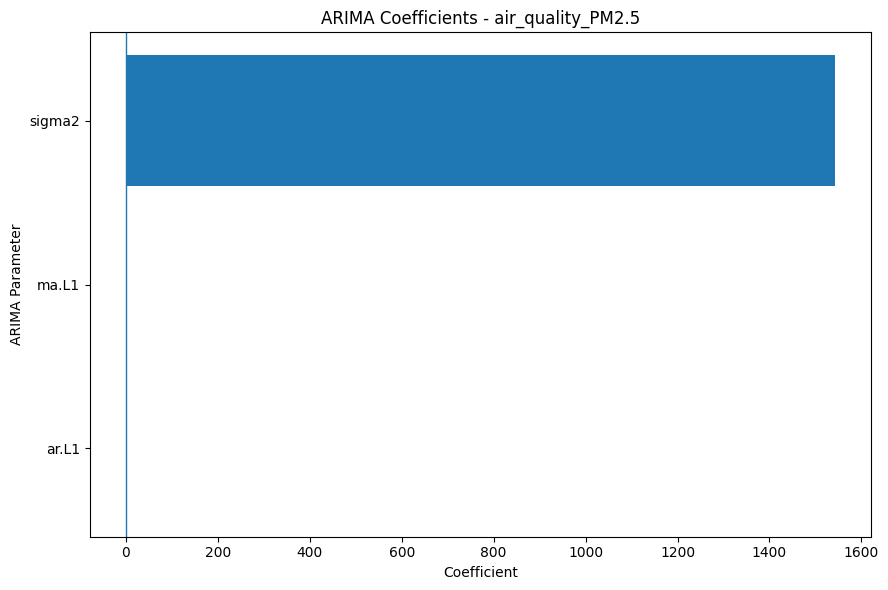

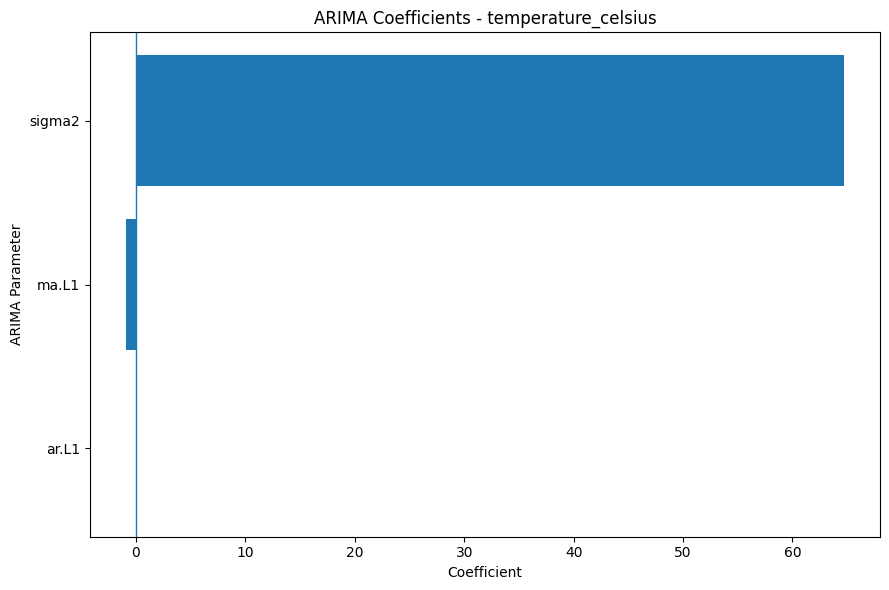

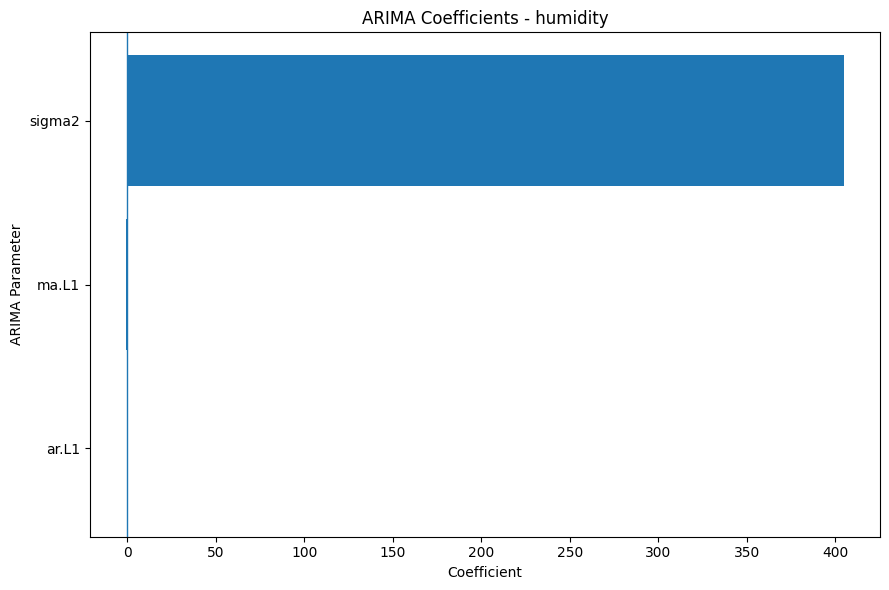

In [13]:
# ============================================================
# COEFFICIENT BAR PLOTS
# ============================================================

for target in targets:

    parameter_df = (
        arima_results[target]["parameters"]
        .copy()
        .sort_values(
            "Absolute_Coefficient",
            ascending=True
        )
    )

    plt.figure(figsize=(9, 6))

    plt.barh(
        parameter_df["Parameter"],
        parameter_df["Coefficient"]
    )

    plt.axvline(
        0,
        linewidth=1
    )

    plt.title(
        f"ARIMA Coefficients - {target}"
    )

    plt.xlabel("Coefficient")
    plt.ylabel("ARIMA Parameter")
    plt.tight_layout()

    plt.savefig(
        f"{save_dir}/01_ARIMA_Coefficients_"
        f"{safe_name(target)}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

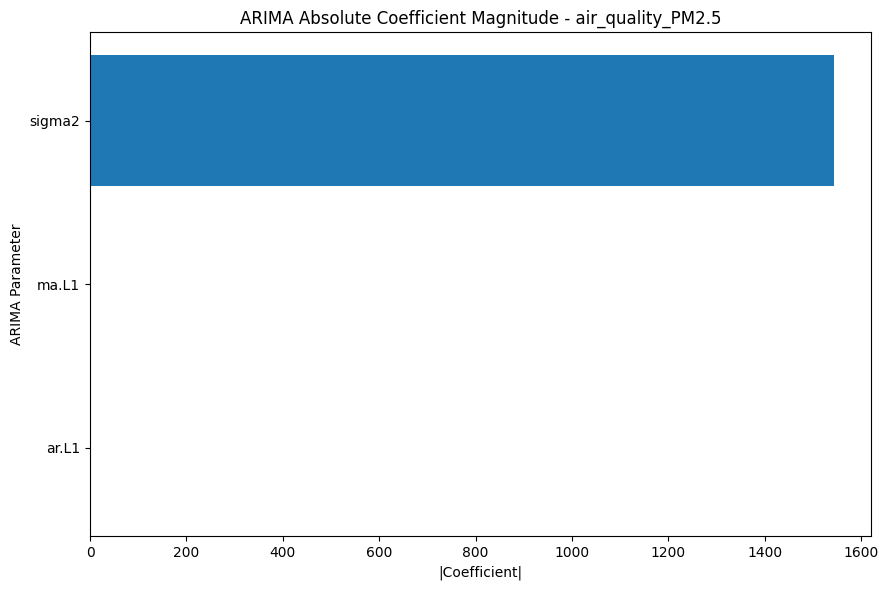

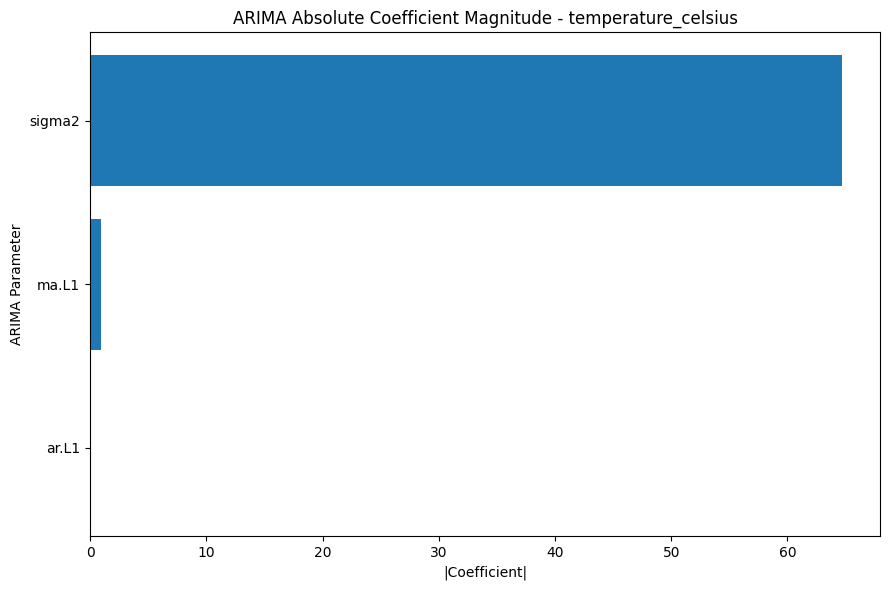

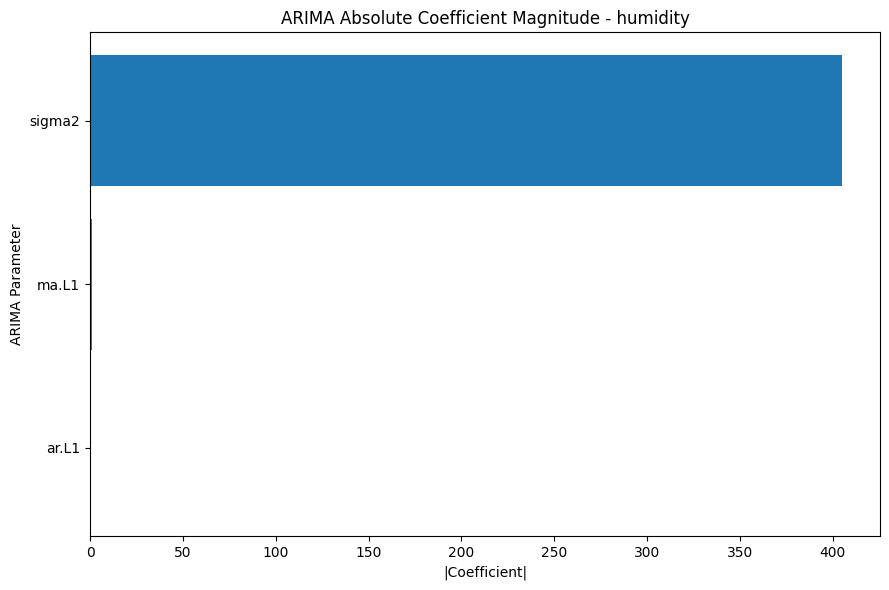

In [14]:
# ============================================================
# ABSOLUTE COEFFICIENT IMPORTANCE
# ============================================================

for target in targets:

    parameter_df = (
        arima_results[target]["parameters"]
        .copy()
        .sort_values(
            "Absolute_Coefficient",
            ascending=True
        )
    )

    plt.figure(figsize=(9, 6))

    plt.barh(
        parameter_df["Parameter"],
        parameter_df["Absolute_Coefficient"]
    )

    plt.title(
        f"ARIMA Absolute Coefficient Magnitude - {target}"
    )

    plt.xlabel("|Coefficient|")
    plt.ylabel("ARIMA Parameter")
    plt.tight_layout()

    plt.savefig(
        f"{save_dir}/02_ARIMA_Absolute_Coefficients_"
        f"{safe_name(target)}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

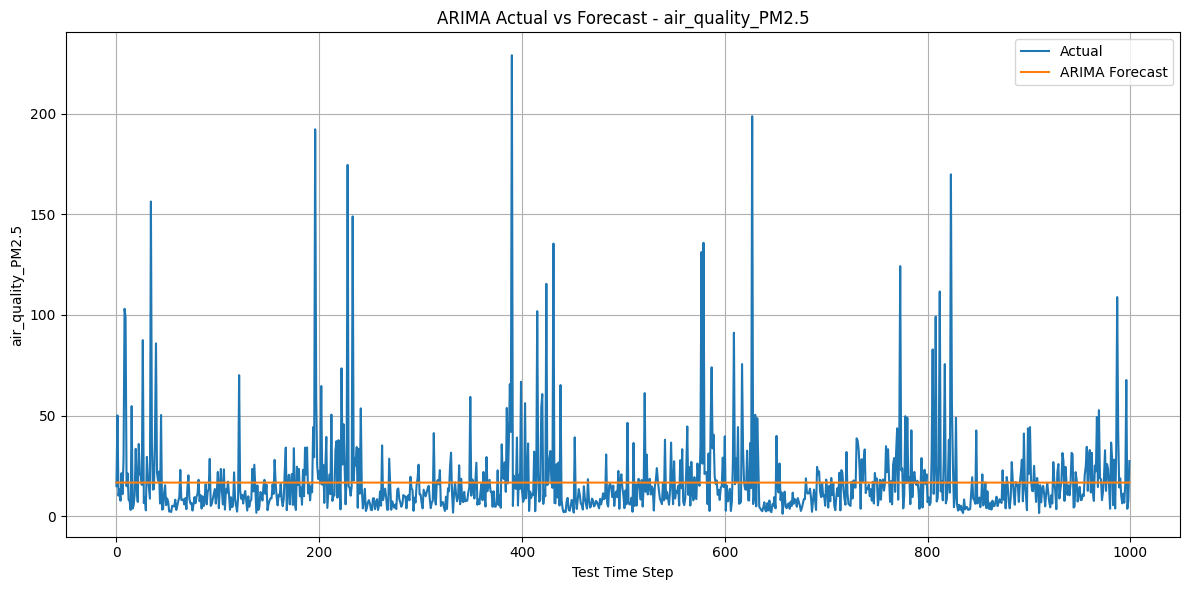

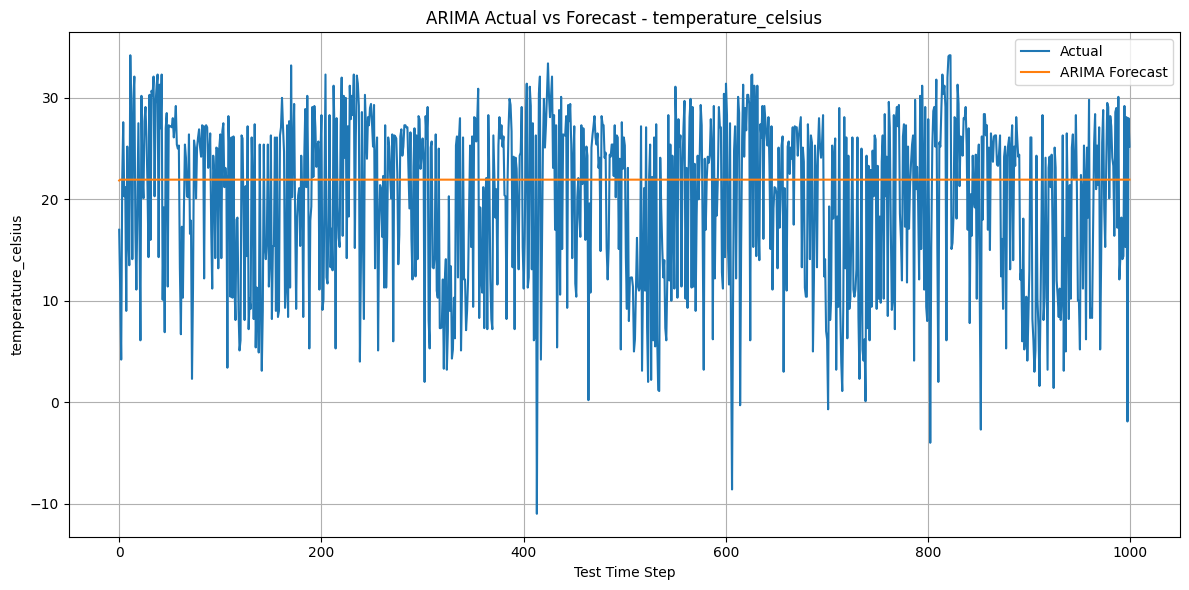

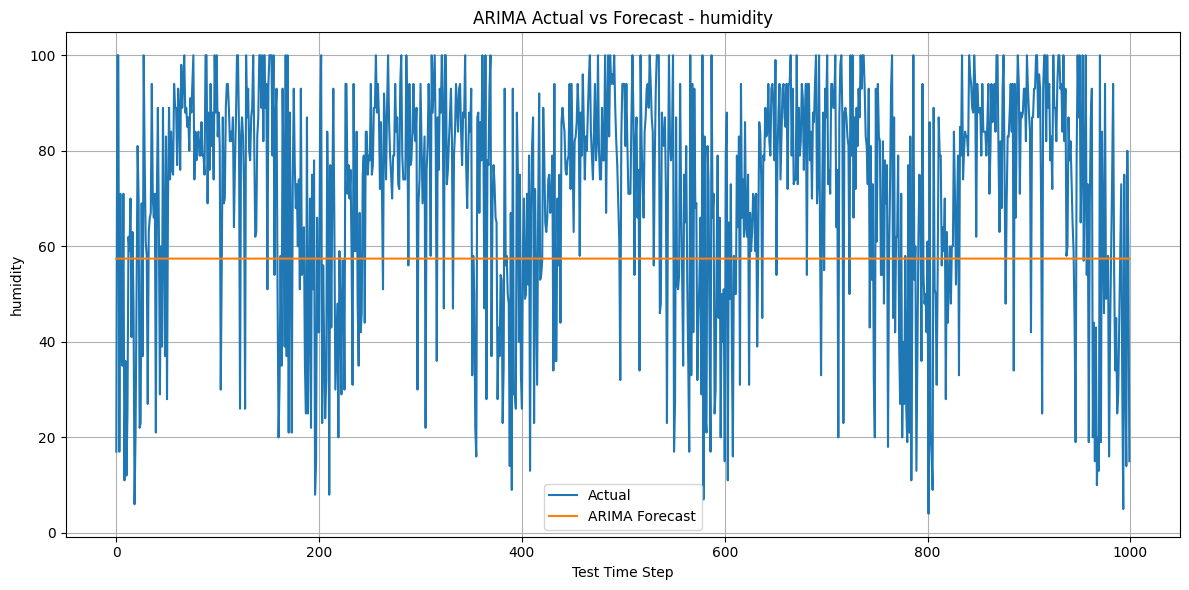

In [15]:
# ============================================================
# ACTUAL VS FORECAST
# ============================================================

PLOT_COUNT = 1000

for target in targets:

    y_true = arima_results[target]["actual"]
    y_pred = arima_results[target]["forecast"]

    plot_n = min(
        PLOT_COUNT,
        len(y_true)
    )

    plt.figure(figsize=(12, 6))

    plt.plot(
        y_true[:plot_n],
        label="Actual"
    )

    plt.plot(
        y_pred[:plot_n],
        label="ARIMA Forecast"
    )

    plt.title(
        f"ARIMA Actual vs Forecast - {target}"
    )

    plt.xlabel("Test Time Step")
    plt.ylabel(target)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    plt.savefig(
        f"{save_dir}/03_ARIMA_Actual_vs_Forecast_"
        f"{safe_name(target)}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

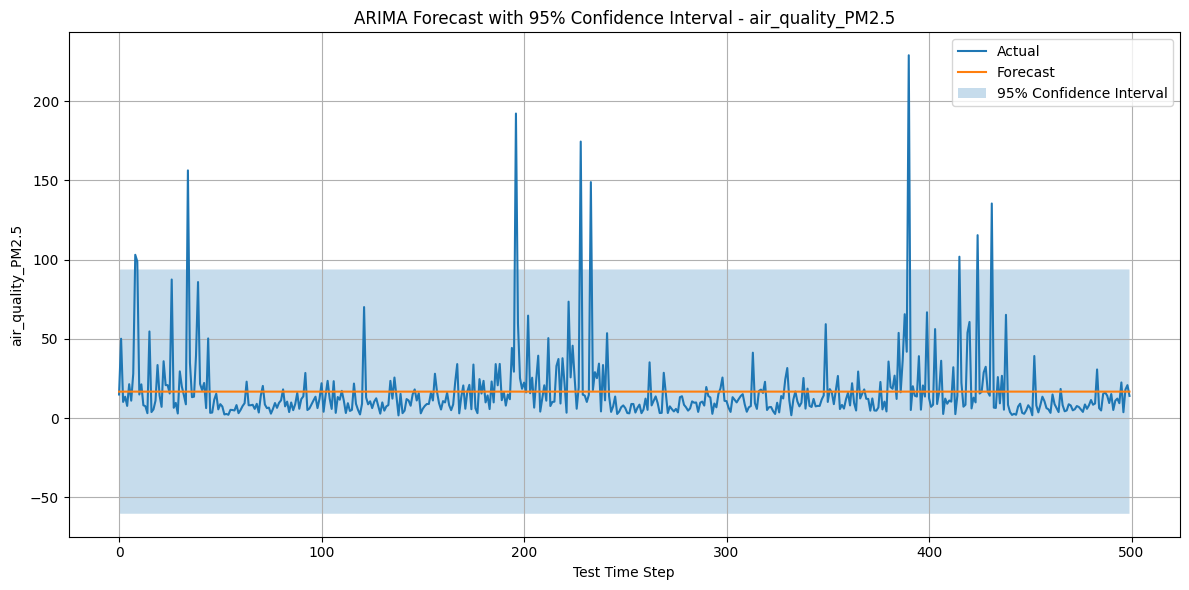

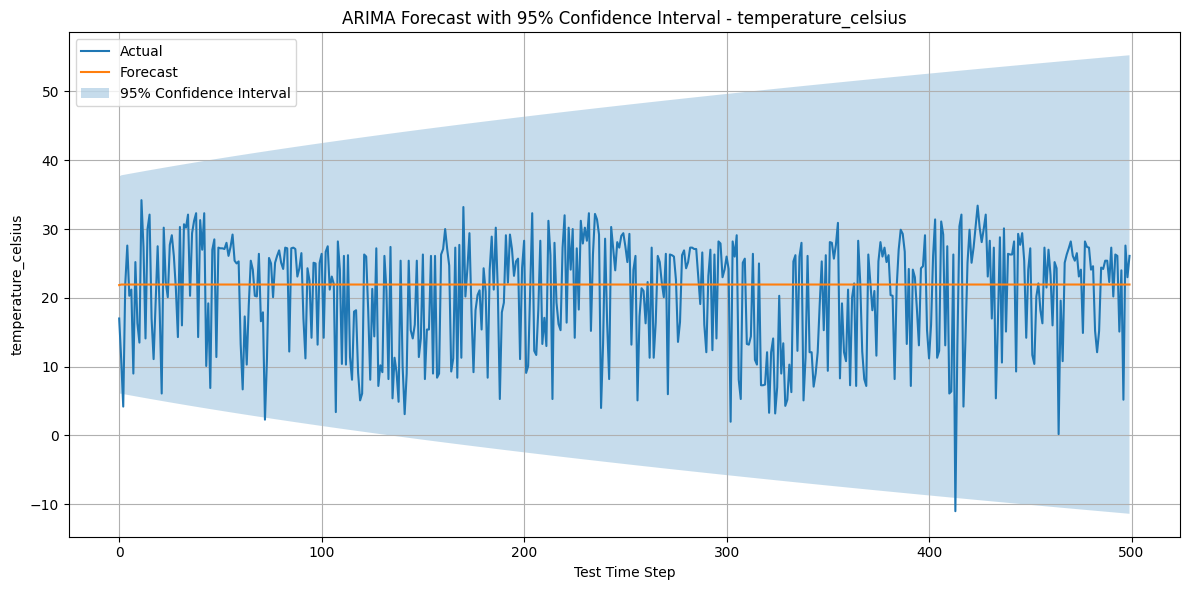

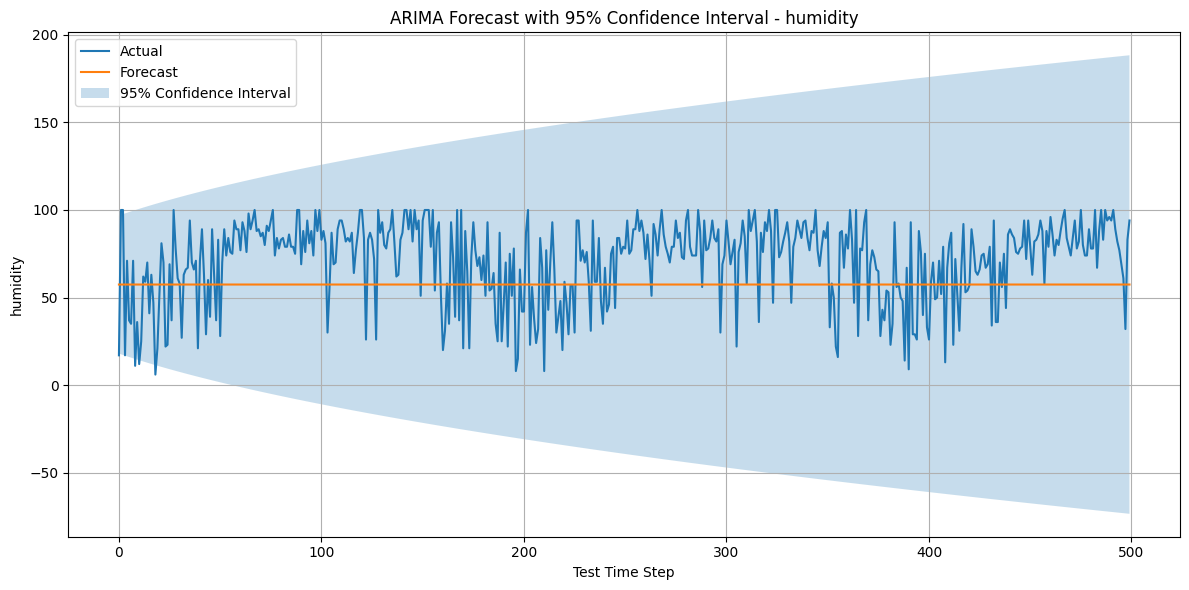

In [16]:
# ============================================================
# FORECAST WITH 95% CONFIDENCE INTERVAL
# ============================================================

CONFIDENCE_PLOT_COUNT = 500

for target in targets:

    y_true = arima_results[target]["actual"]
    y_pred = arima_results[target]["forecast"]
    lower_ci = arima_results[target]["lower_ci"]
    upper_ci = arima_results[target]["upper_ci"]

    plot_n = min(
        CONFIDENCE_PLOT_COUNT,
        len(y_true)
    )

    x_axis = np.arange(plot_n)

    plt.figure(figsize=(12, 6))

    plt.plot(
        x_axis,
        y_true[:plot_n],
        label="Actual"
    )

    plt.plot(
        x_axis,
        y_pred[:plot_n],
        label="Forecast"
    )

    plt.fill_between(
        x_axis,
        lower_ci[:plot_n],
        upper_ci[:plot_n],
        alpha=0.25,
        label="95% Confidence Interval"
    )

    plt.title(
        f"ARIMA Forecast with 95% Confidence Interval - {target}"
    )

    plt.xlabel("Test Time Step")
    plt.ylabel(target)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    plt.savefig(
        f"{save_dir}/04_ARIMA_Forecast_Confidence_Interval_"
        f"{safe_name(target)}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

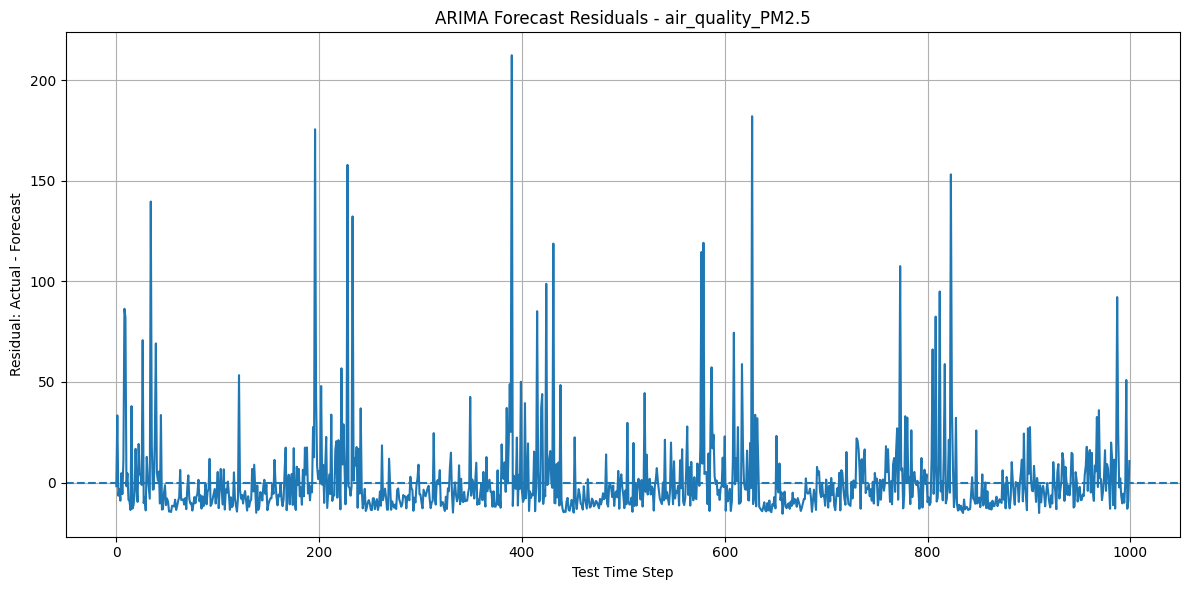

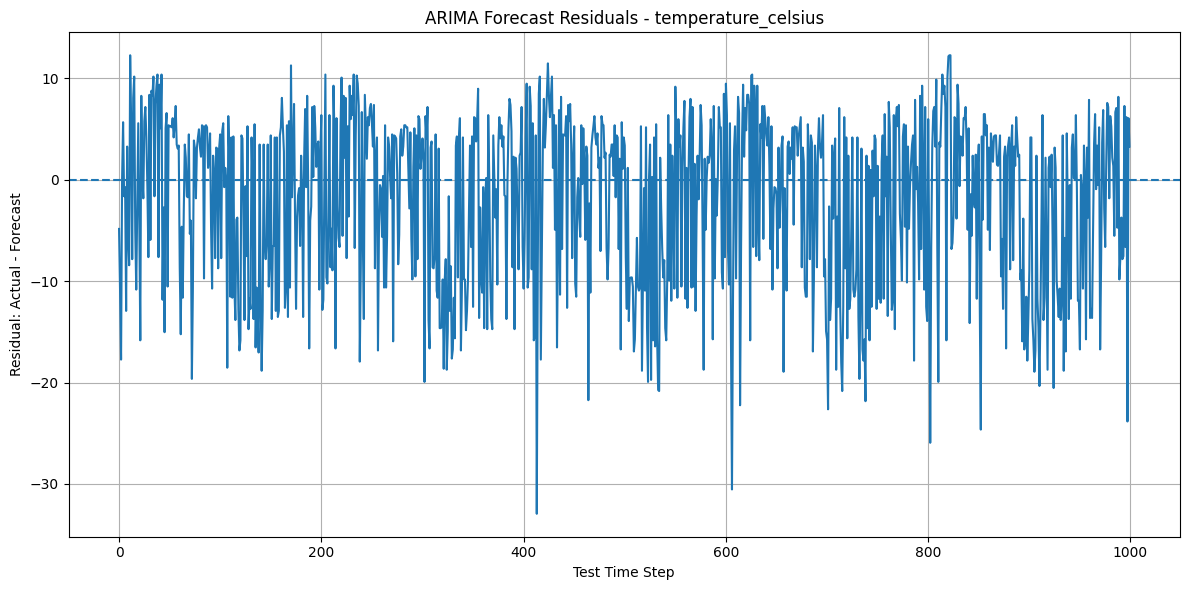

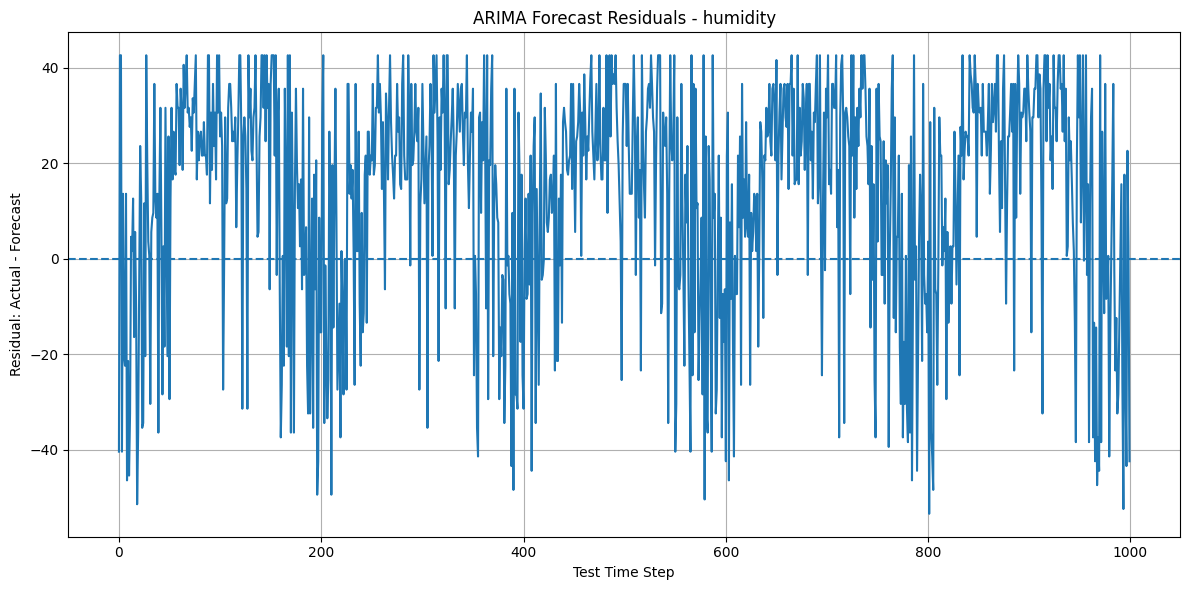

In [17]:
# ============================================================
# FORECAST RESIDUAL PLOTS
# ============================================================

for target in targets:

    residuals = arima_results[target][
        "residuals"
    ]

    plot_n = min(
        PLOT_COUNT,
        len(residuals)
    )

    plt.figure(figsize=(12, 6))

    plt.plot(
        residuals[:plot_n]
    )

    plt.axhline(
        0,
        linestyle="--"
    )

    plt.title(
        f"ARIMA Forecast Residuals - {target}"
    )

    plt.xlabel("Test Time Step")
    plt.ylabel("Residual: Actual - Forecast")
    plt.grid(True)
    plt.tight_layout()

    plt.savefig(
        f"{save_dir}/05_ARIMA_Residual_Plot_"
        f"{safe_name(target)}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

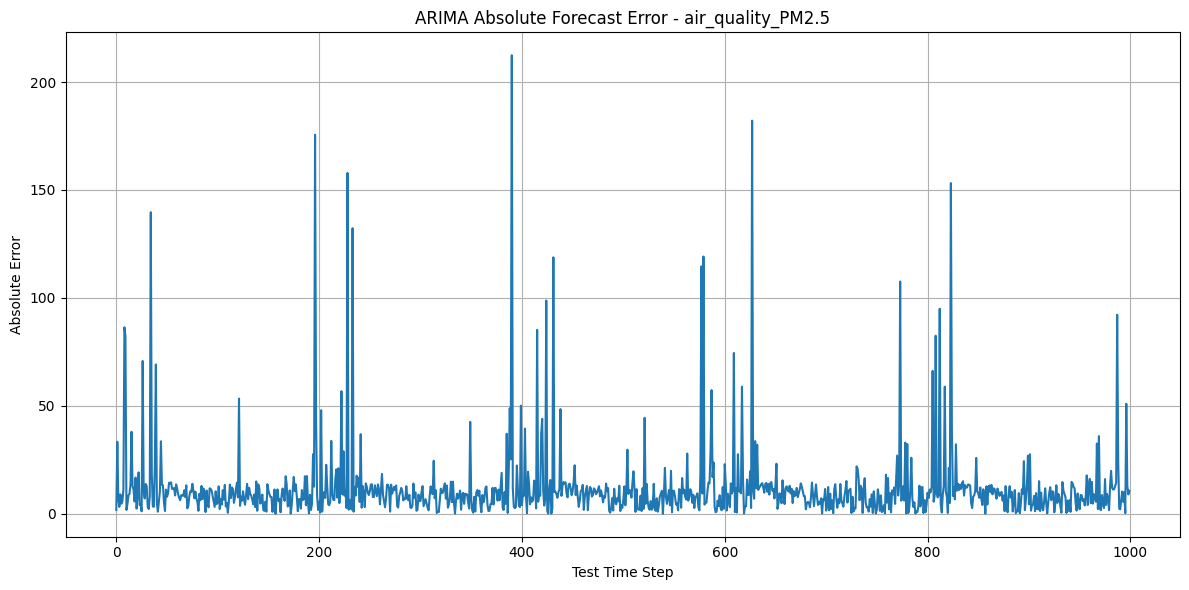

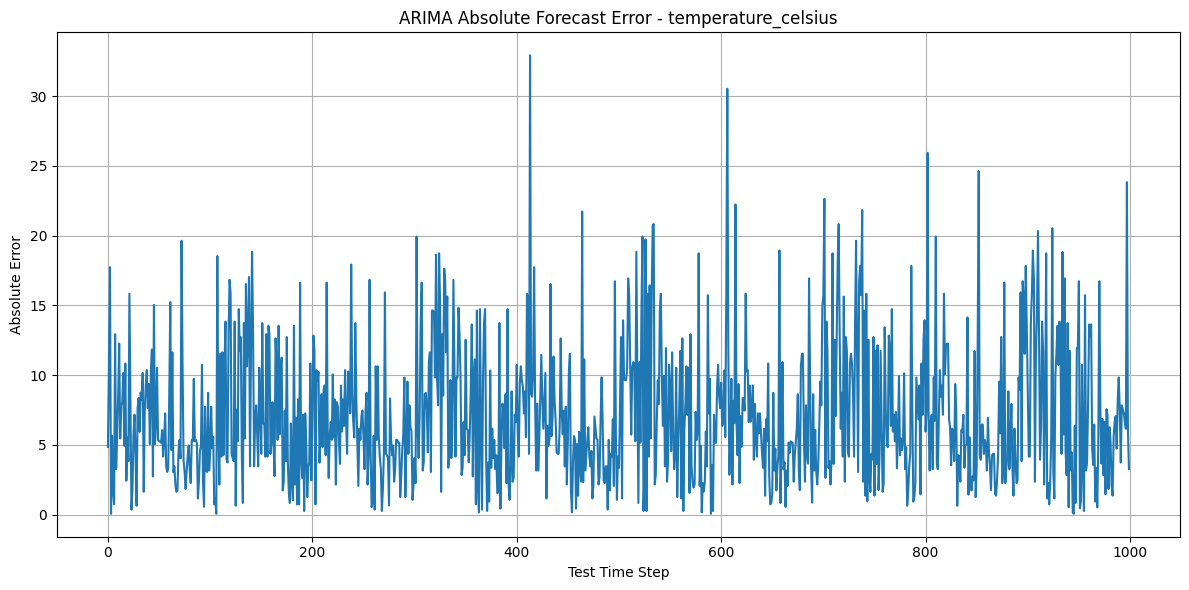

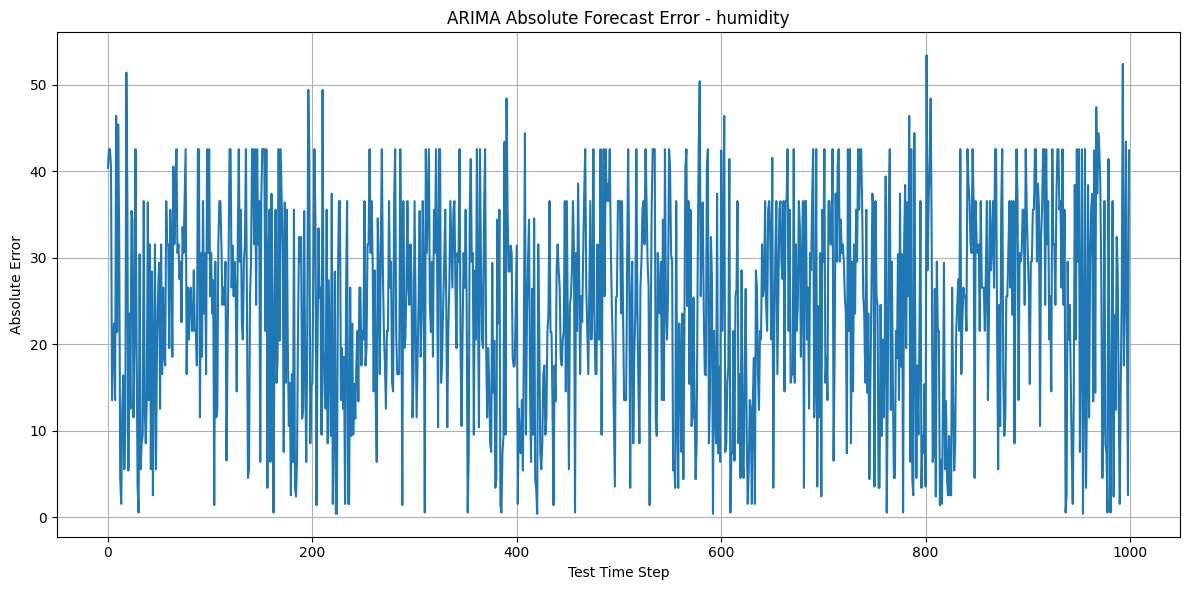

In [18]:
# ============================================================
# ABSOLUTE FORECAST ERROR
# ============================================================

for target in targets:

    absolute_error = arima_results[target][
        "absolute_error"
    ]

    plot_n = min(
        PLOT_COUNT,
        len(absolute_error)
    )

    plt.figure(figsize=(12, 6))

    plt.plot(
        absolute_error[:plot_n]
    )

    plt.title(
        f"ARIMA Absolute Forecast Error - {target}"
    )

    plt.xlabel("Test Time Step")
    plt.ylabel("Absolute Error")
    plt.grid(True)
    plt.tight_layout()

    plt.savefig(
        f"{save_dir}/06_ARIMA_Absolute_Error_"
        f"{safe_name(target)}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

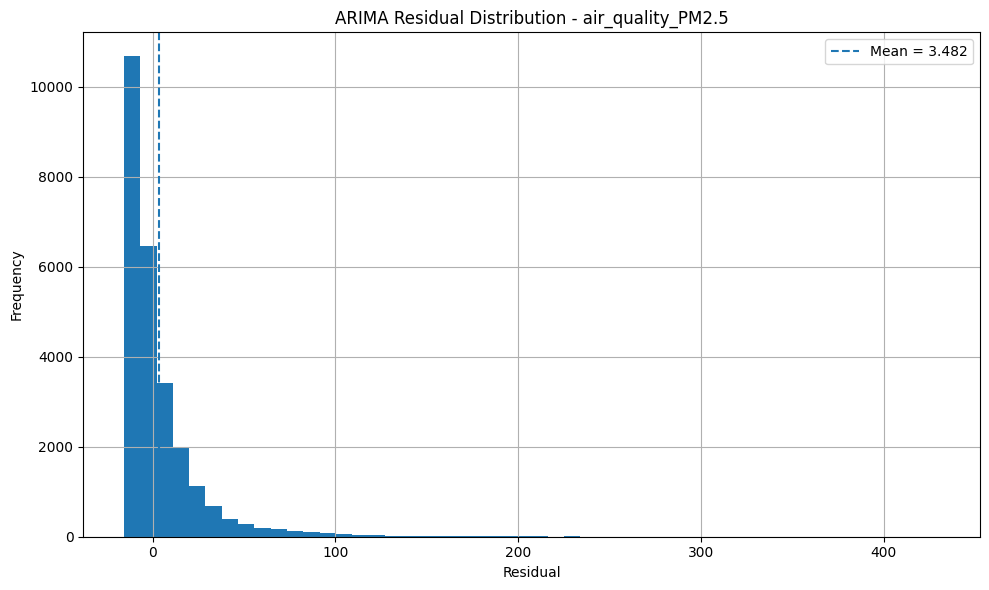

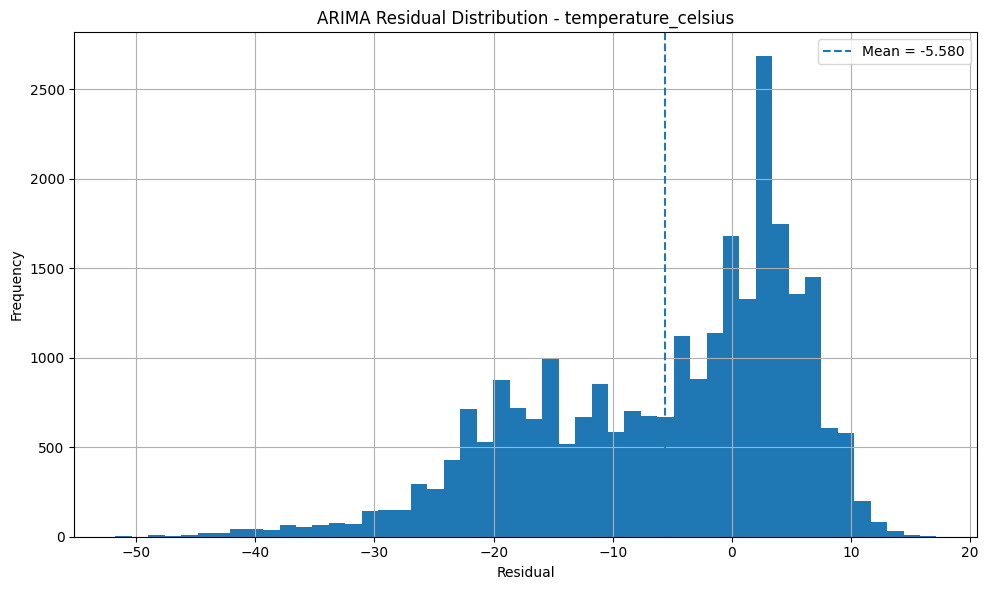

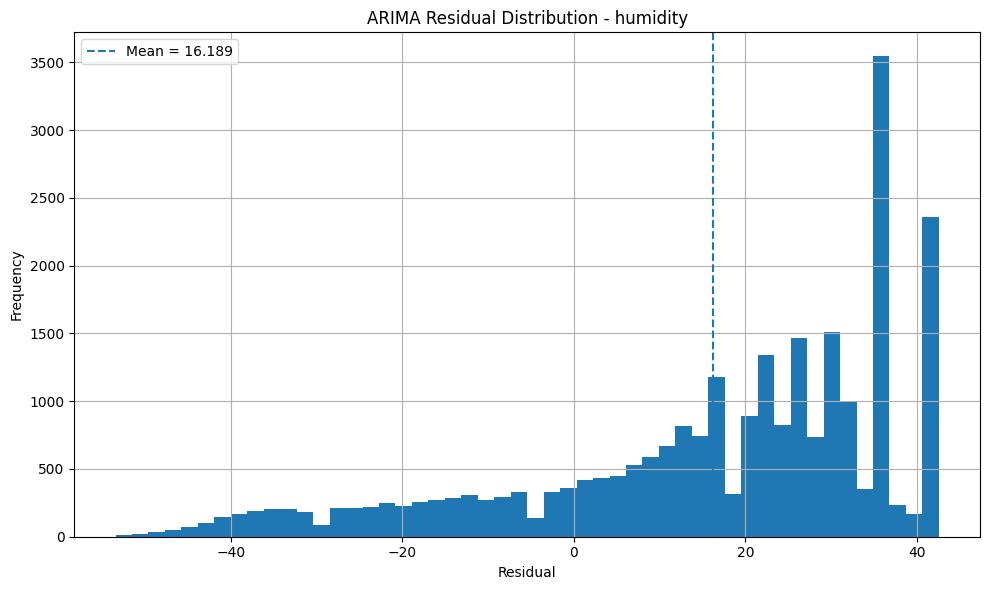

In [19]:
# ============================================================
# RESIDUAL DISTRIBUTION
# ============================================================

for target in targets:

    residuals = arima_results[target][
        "residuals"
    ]

    plt.figure(figsize=(10, 6))

    plt.hist(
        residuals,
        bins=50
    )

    plt.axvline(
        np.mean(residuals),
        linestyle="--",
        label=f"Mean = {np.mean(residuals):.3f}"
    )

    plt.title(
        f"ARIMA Residual Distribution - {target}"
    )

    plt.xlabel("Residual")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    plt.savefig(
        f"{save_dir}/07_ARIMA_Residual_Distribution_"
        f"{safe_name(target)}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

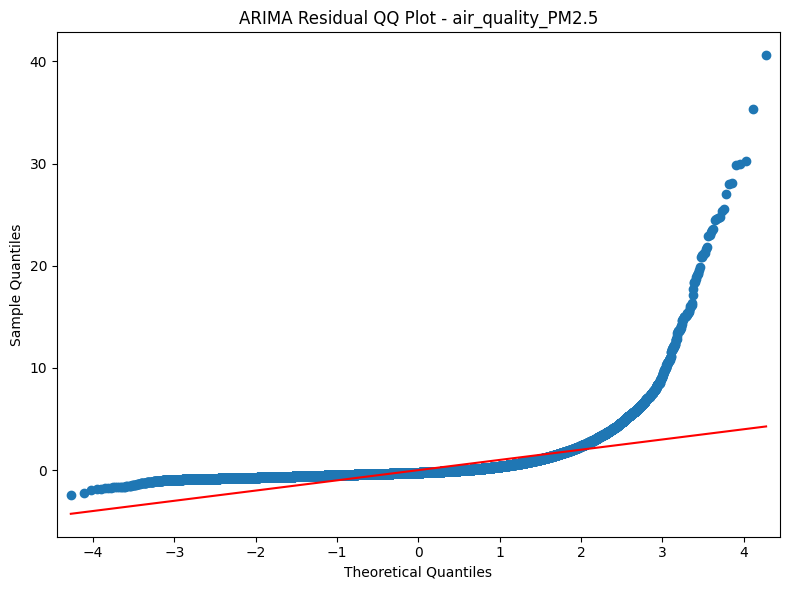

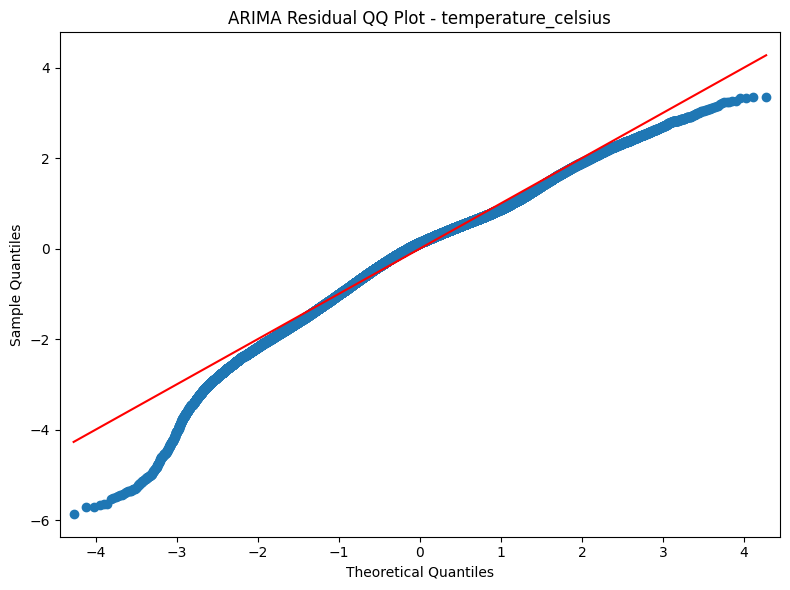

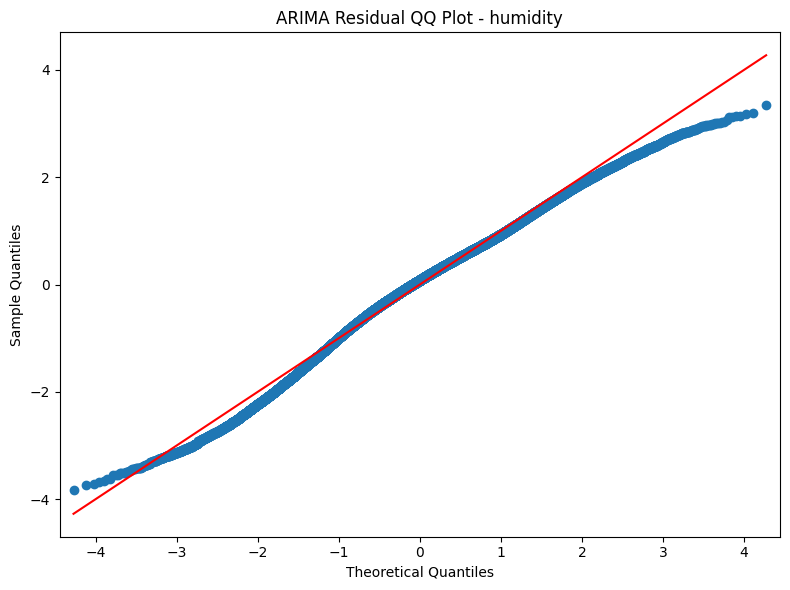

In [20]:
# ============================================================
# QQ PLOTS
# ============================================================

for target in targets:

    residuals = arima_results[target][
        "fitted_residuals"
    ]

    fig = plt.figure(figsize=(8, 6))

    qqplot(
        residuals,
        line="s",
        fit=True,
        ax=fig.add_subplot(111)
    )

    plt.title(
        f"ARIMA Residual QQ Plot - {target}"
    )

    plt.tight_layout()

    plt.savefig(
        f"{save_dir}/08_ARIMA_QQ_Plot_"
        f"{safe_name(target)}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

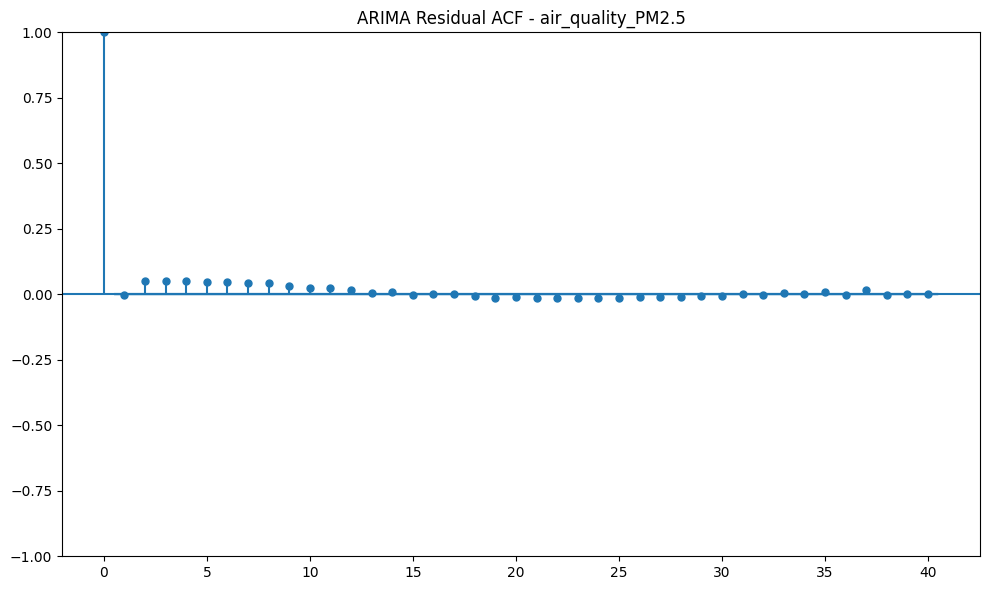

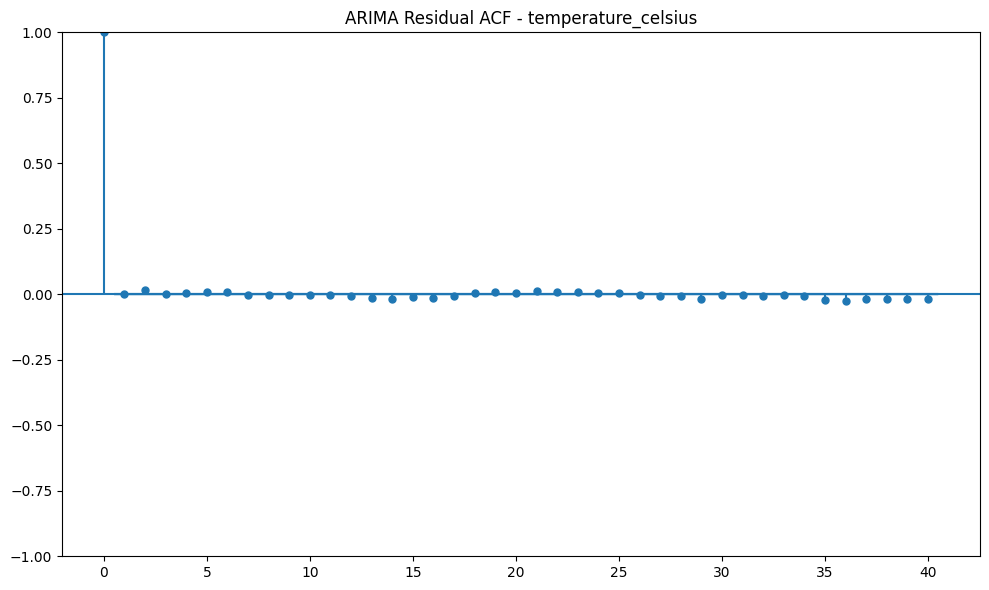

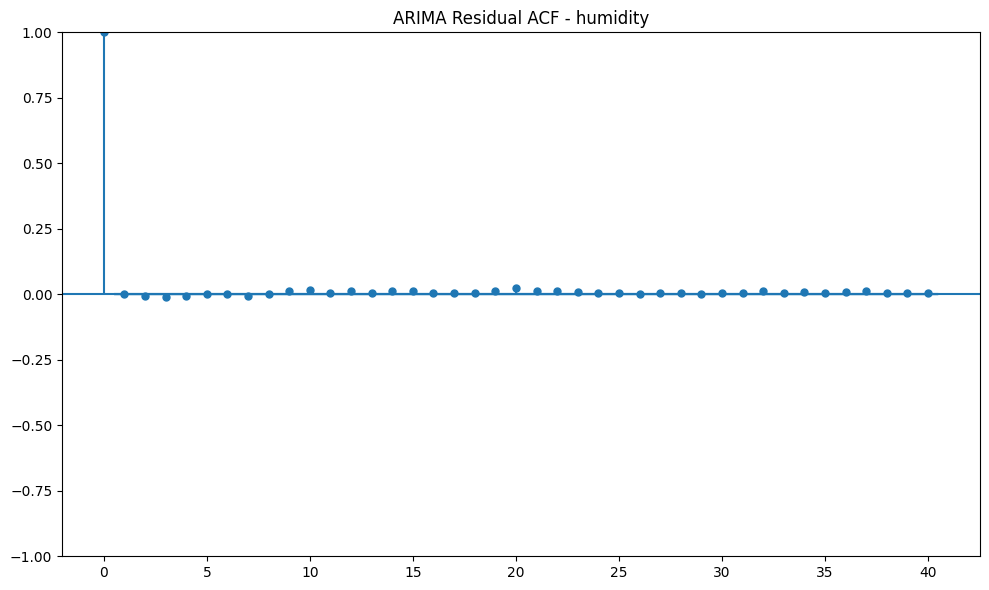

In [21]:
# ============================================================
# RESIDUAL ACF
# ============================================================

for target in targets:

    residuals = arima_results[target][
        "fitted_residuals"
    ]

    max_lags = min(
        40,
        max(1, len(residuals) // 2 - 1)
    )

    fig, ax = plt.subplots(
        figsize=(10, 6)
    )

    plot_acf(
        residuals,
        lags=max_lags,
        ax=ax
    )

    ax.set_title(
        f"ARIMA Residual ACF - {target}"
    )

    plt.tight_layout()

    plt.savefig(
        f"{save_dir}/09_ARIMA_Residual_ACF_"
        f"{safe_name(target)}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

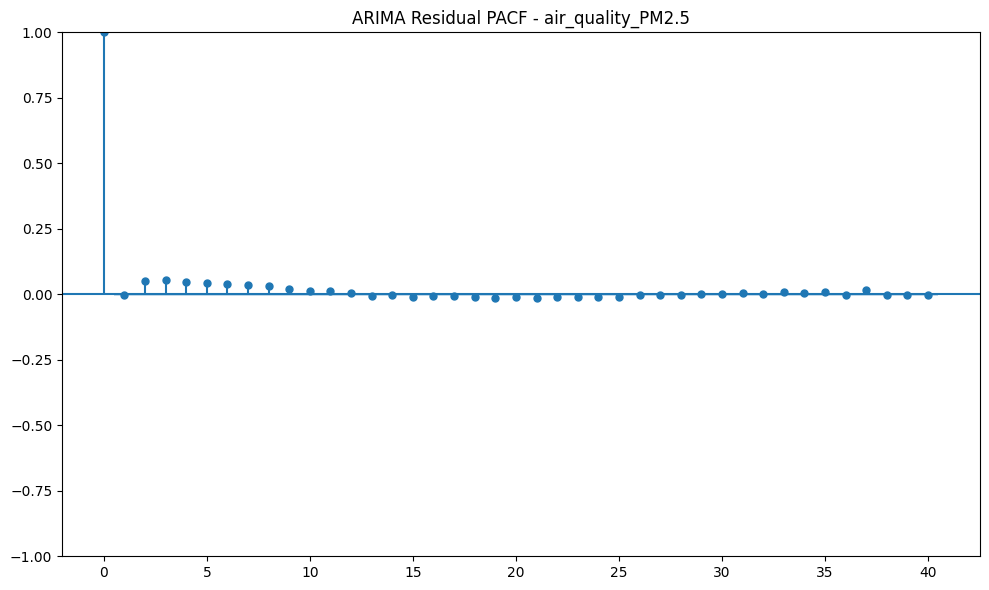

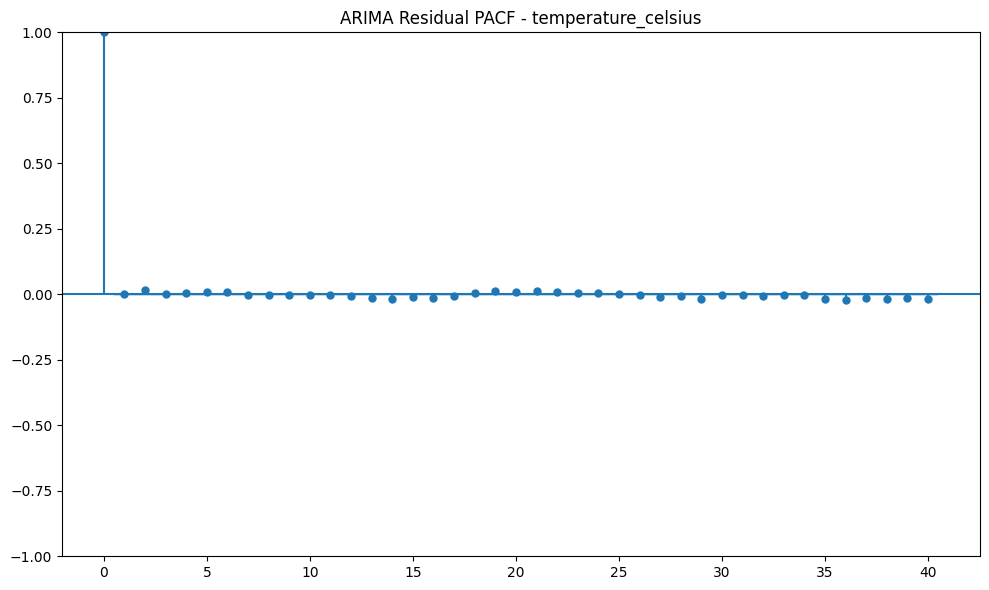

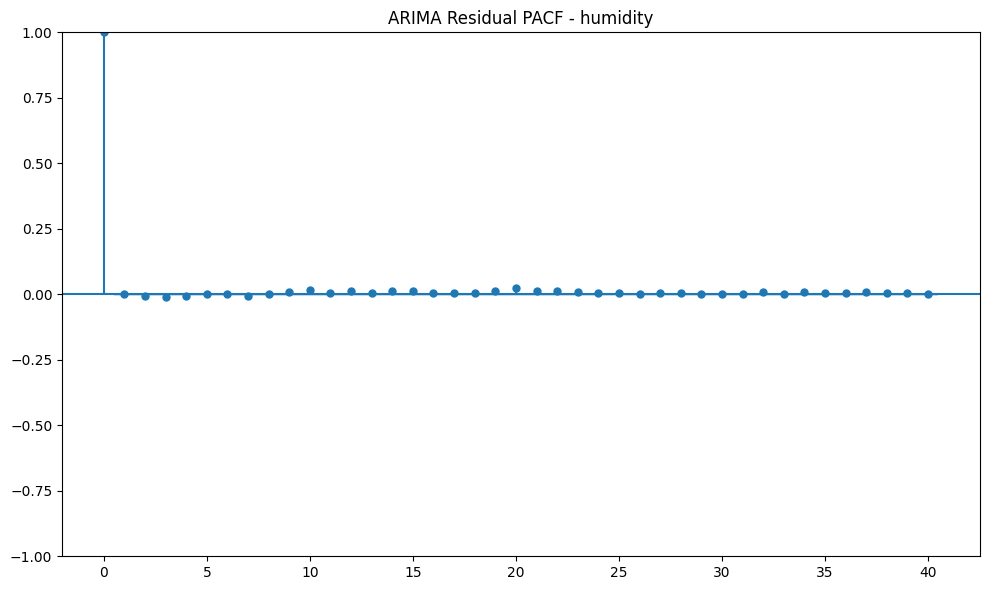

In [22]:
# ============================================================
# RESIDUAL PACF
# ============================================================

for target in targets:

    residuals = arima_results[target][
        "fitted_residuals"
    ]

    max_lags = min(
        40,
        max(1, len(residuals) // 2 - 1)
    )

    fig, ax = plt.subplots(
        figsize=(10, 6)
    )

    plot_pacf(
        residuals,
        lags=max_lags,
        method="ywm",
        ax=ax
    )

    ax.set_title(
        f"ARIMA Residual PACF - {target}"
    )

    plt.tight_layout()

    plt.savefig(
        f"{save_dir}/10_ARIMA_Residual_PACF_"
        f"{safe_name(target)}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

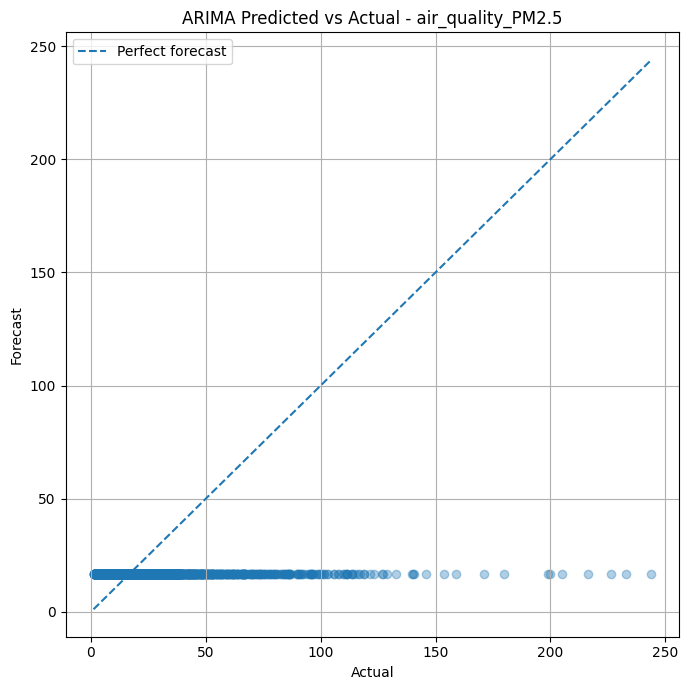

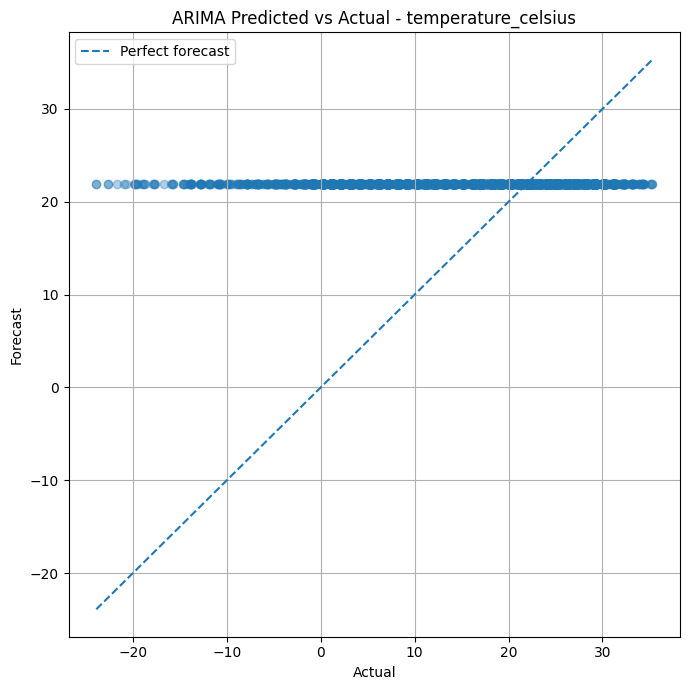

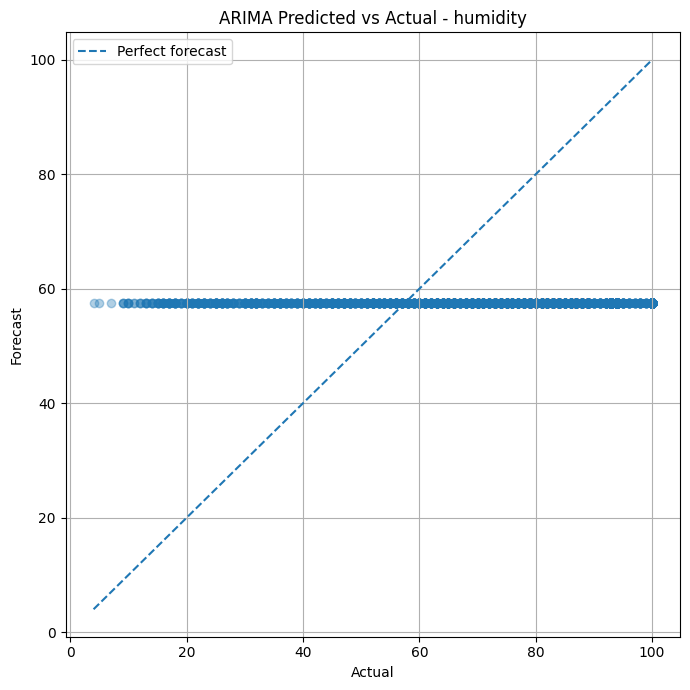

In [23]:
# ============================================================
# PREDICTED VS ACTUAL SCATTER
# ============================================================

SCATTER_COUNT = 3000
rng = np.random.default_rng(42)

for target in targets:

    y_true = arima_results[target]["actual"]
    y_pred = arima_results[target]["forecast"]

    sample_n = min(
        SCATTER_COUNT,
        len(y_true)
    )

    selected_indices = rng.choice(
        len(y_true),
        size=sample_n,
        replace=False
    )

    actual_sample = y_true[selected_indices]
    predicted_sample = y_pred[selected_indices]

    minimum = min(
        actual_sample.min(),
        predicted_sample.min()
    )

    maximum = max(
        actual_sample.max(),
        predicted_sample.max()
    )

    plt.figure(figsize=(7, 7))

    plt.scatter(
        actual_sample,
        predicted_sample,
        alpha=0.35
    )

    plt.plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--",
        label="Perfect forecast"
    )

    plt.title(
        f"ARIMA Predicted vs Actual - {target}"
    )

    plt.xlabel("Actual")
    plt.ylabel("Forecast")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    plt.savefig(
        f"{save_dir}/11_ARIMA_Predicted_vs_Actual_"
        f"{safe_name(target)}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

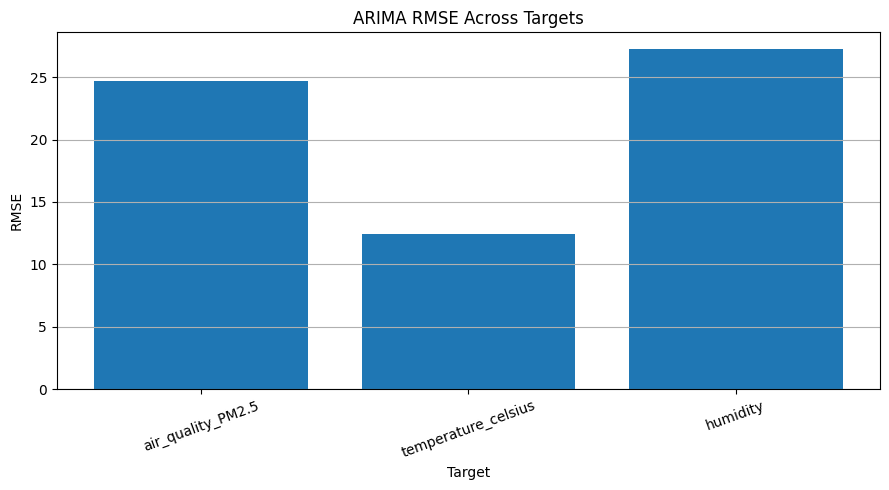

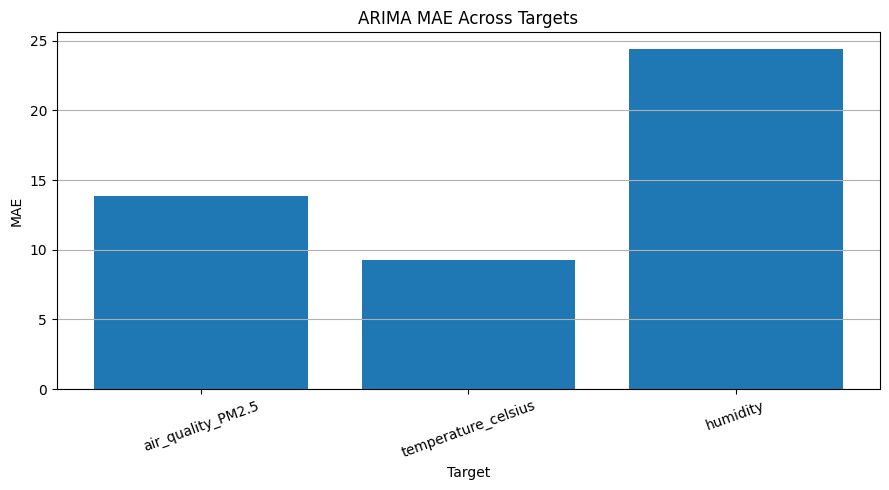

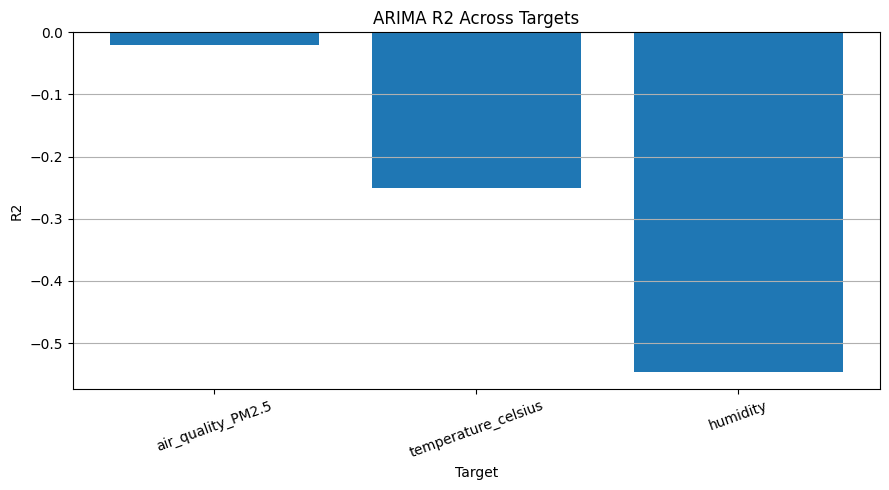

In [24]:
# ============================================================
# METRIC COMPARISON ACROSS TARGETS
# ============================================================

for metric_name in [
    "RMSE",
    "MAE",
    "R2"
]:

    plt.figure(figsize=(9, 5))

    plt.bar(
        metrics_df["Target"],
        metrics_df[metric_name]
    )

    plt.title(
        f"ARIMA {metric_name} Across Targets"
    )

    plt.xlabel("Target")
    plt.ylabel(metric_name)
    plt.xticks(rotation=20)
    plt.grid(axis="y")
    plt.tight_layout()

    plt.savefig(
        f"{save_dir}/12_ARIMA_{metric_name}_"
        f"Comparison_All_Targets.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

In [25]:
# ============================================================
# SAVE FULL ARIMA MODEL SUMMARIES
# ============================================================

for target in targets:

    arima_fit = arima_results[target]["fit"]

    summary_text = (
        arima_fit.summary().as_text()
    )

    summary_path = (
        f"{save_dir}/ARIMA_Model_Summary_"
        f"{safe_name(target)}.txt"
    )

    with open(
        summary_path,
        "w"
    ) as file:

        file.write(summary_text)

print("Model summaries saved.")

Model summaries saved.


In [26]:
# ============================================================
# ZIP AND DOWNLOAD ALL OUTPUTS
# ============================================================

zip_path = (
    "/content/"
    "Multi_Target_ARIMA_XAI_Outputs.zip"
)

with zipfile.ZipFile(
    zip_path,
    mode="w",
    compression=zipfile.ZIP_DEFLATED
) as zip_file:

    for root, directories, filenames in os.walk(
        save_dir
    ):

        for filename in filenames:

            file_path = os.path.join(
                root,
                filename
            )

            archive_name = os.path.relpath(
                file_path,
                save_dir
            )

            zip_file.write(
                file_path,
                arcname=archive_name
            )

print("ZIP created successfully:")
print(zip_path)

files.download(zip_path)

ZIP created successfully:
/content/Multi_Target_ARIMA_XAI_Outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>